# This file contains Processes Exercises of Lectures 1 & 2

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pathlib import Path
from cartopy.io import shapereader
from rich import print
import matplotlib.pyplot as plt
import xarray as xr

# Loading the Data Cagayan de Oro

In [3]:
# Name of shapefile/region
own_region = "Cagayan_de_Oro"

# Shapefile that describes the basin we want to study
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}_1991_2019_Forcing"

#Shape area
shape_area_Cagayan = 1083.18 * 1000000 #1453933257.379 # m2

# Load ERA5 data
ERA5_forcing_Cagayan = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)

In [4]:
# Name of shapefile/region
own_region = "Tagoloan"

# Shapefile that describes the basin we want to study
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}_2013_2019_Forcing"

#Shape area
shape_area_Tagoloan = 1670.10 * 1000000 # m2

# Load ERA5 data
ERA5_forcing_Tagoloan = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)

In [5]:
# Period of interest
experiment_start_time = "2003-01-01T00:00:00Z"
experiment_end_time = "2012-12-31T00:00:00Z"

In [6]:
# Load evap and prec Cagayan de Oro
C_evap = ERA5_forcing_Cagayan.to_xarray()["evspsblpot"]
C_prec = ERA5_forcing_Cagayan.to_xarray()["pr"]
C_evap = C_evap * 86400 # mm/day
C_prec = C_prec * 86400 # mm/day

# Load evap and prec Tagoloan
T_evap = ERA5_forcing_Tagoloan.to_xarray()["evspsblpot"]
T_prec = ERA5_forcing_Tagoloan.to_xarray()["pr"]
T_evap = T_evap * 86400 # mm/day
T_prec = T_prec * 86400 # mm/day

In [7]:
# Discharge data Cagayan de Oro
C_obs = pd.read_excel('Discharge_19912019_Cagayan.xlsx', index_col=[0])
C_obs = C_obs / 1000 # m3/s
C_obs = C_obs * 86400 / shape_area_Cagayan * 1000 # mm/day
C_obs.loc[C_obs['Q'] > 4000, 'Q'] = np.nan
C_obs_1 = C_obs.loc['2003-01-01':'2012-12-31']
C_obs_data = C_obs_1['Q'].to_xarray().rename({'Day': 'time'})

In [8]:
# Discharge data Tagoloan
T_obs = pd.read_excel('Discharge_20132019_Tagoloan.xlsx', index_col=[0])
T_obs = T_obs / 1000 # m3/s
T_obs = T_obs * 86400 / shape_area_Tagoloan * 1000 # mm/day
T_obs.loc[T_obs['Q'] > 4000, 'Q'] = np.nan
T_obs = T_obs.loc['2013-01-01':'2019-12-31']
T_obs_data = T_obs['Q'].to_xarray().rename({'Day': 'time'})

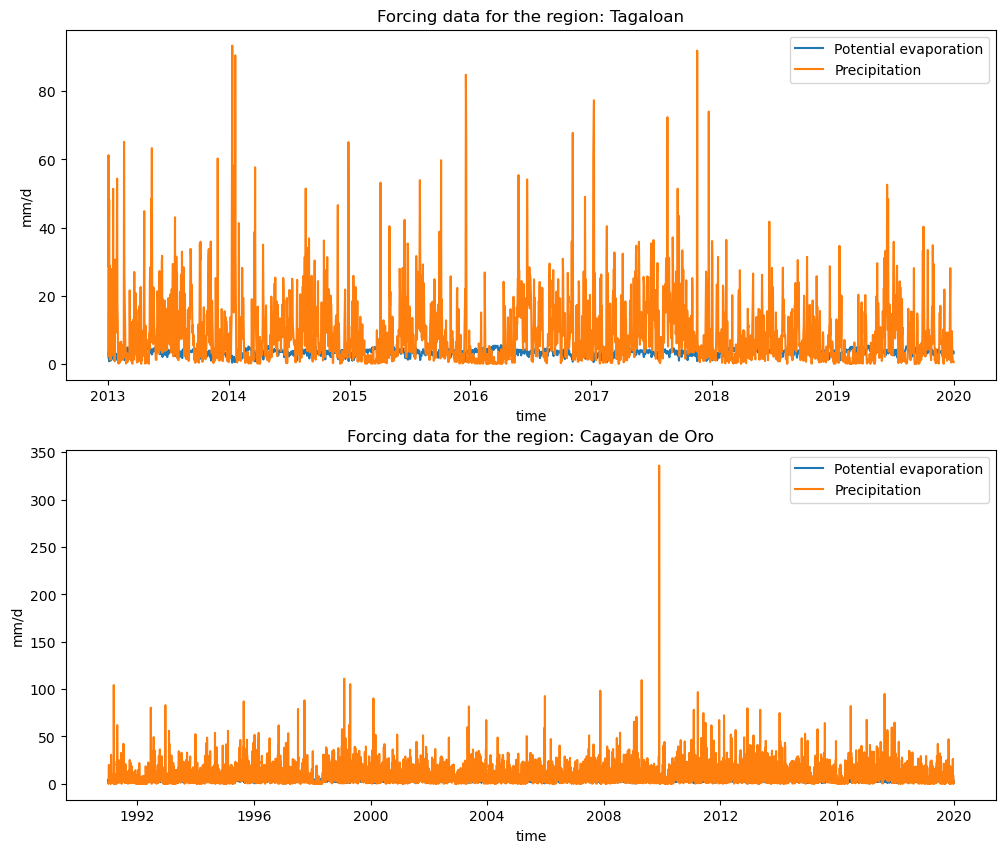

In [9]:
# Test
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12,10))

T_evap.plot(ax=axs[0], label='Potential evaporation')
T_prec.plot(ax=axs[0], label='Precipitation')
axs[0].set_title(f'Forcing data for the region: Tagaloan')
axs[0].set_ylabel('mm/d')
axs[0].legend()

C_evap.plot(ax=axs[1], label='Potential evaporation')
C_prec.plot(ax=axs[1], label='Precipitation')
axs[1].set_title(f'Forcing data for the region: Cagayan de Oro')
axs[1].set_ylabel('mm/d')
axs[1].legend();

# Processes 1.1: Catchment Functioning, Macroscale Laws & Change

In [10]:
C_evap["time"] = C_evap["time"].dt.date
C_prec["time"] = C_prec["time"].dt.date
T_evap["time"] = T_evap["time"].dt.date
T_prec["time"] = T_prec["time"].dt.date

In [11]:
C_evap.name = "EP mm/d" 
C_prec.name = "P mm/d"
C_obs_data.name = "Q mm/d"

df = xr.merge([C_prec, C_evap, C_obs_data]).to_dataframe()
Cagayan = df[["P mm/d", "EP mm/d", "Q mm/d"]].dropna()
Cagayan.index = pd.to_datetime(Cagayan.index)
Cagayan

,P mm/d,EP mm/d,Q mm/d
time,,,
2003-01-01,9.684547,3.070720,3.811816
2003-01-02,0.715086,3.750266,3.707882
2003-01-03,2.884134,2.304247,3.603948
2003-01-04,14.804321,3.002807,3.603948
2003-01-05,1.663581,3.253148,5.647372
...,...,...,...
2012-12-27,5.784280,2.979239,5.048335
2012-12-28,0.787491,3.415124,5.048335
2012-12-29,0.977529,3.770076,5.048335


In [12]:
T_evap.name = "EP mm/d" 
T_prec.name = "P mm/d" 
T_obs_data.name = "Q mm/d"

df = xr.merge([T_prec, T_evap, T_obs_data]).to_dataframe()
Tagoloan = df[["P mm/d", "EP mm/d", "Q mm/d"]].dropna()
Tagoloan.index = pd.to_datetime(Tagoloan.index)
Tagoloan

,P mm/d,EP mm/d,Q mm/d
time,,,
2013-01-18,2.727902,3.381890,4.831902
2013-01-19,11.383754,1.061304,5.354410
2013-01-20,1.549613,2.731830,9.533436
2013-01-21,0.735289,3.090874,4.914676
2013-01-22,30.597606,0.973964,4.122637
...,...,...,...
2019-09-23,5.792398,4.396816,1.872750
2019-09-24,1.107592,4.824052,1.844297
2019-09-25,3.119946,4.770987,1.787390


In [13]:
# Budyko line
ep_p = np.arange(0.01, 5.25, 0.25)
budyko = (ep_p * np.tanh(1 / ep_p) * (1 - np.exp(-ep_p))) ** (1/2)

# Cagayan de Oro
# EP / P
EP_P = Cagayan['EP mm/d'].mean() / Cagayan['P mm/d'].mean()

# Budyko
EA_P_b = (EP_P * np.tanh(1 / EP_P) * (1 - np.exp(-EP_P))) ** (1/2)

# Water balance
EA_P_w = 1 - Cagayan['Q mm/d'].mean() / Cagayan['P mm/d'].mean()

In [14]:
# Tagoloan
# EP / P
EP_P2 = Tagoloan['EP mm/d'].mean() / Tagoloan['P mm/d'].mean()

# Budyko
EA_P_b2 = (EP_P2 * np.tanh(1 / EP_P2) * (1 - np.exp(-EP_P2))) ** (1/2)

# Water balance
EA_P_w2 = 1 - Tagoloan['Q mm/d'].mean() / Tagoloan['P mm/d'].mean()

In [15]:
# Limits
EP_energy_limit = np.array([0,1])
EA_energy_limit = np.array([0,1])
EP_water_limit = np.arange(1,6)
EA_water_limit = np.ones(5)

Text(0, 0.5, 'Ea / P [-]')

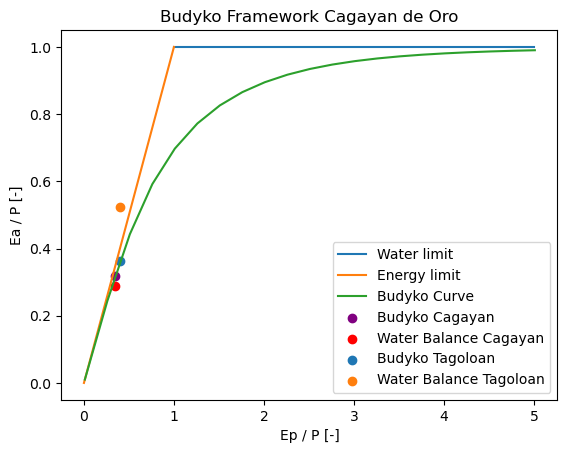

In [16]:
# Plot
plt.plot(EP_water_limit, EA_water_limit, label='Water limit')
plt.plot(EP_energy_limit, EA_energy_limit, label='Energy limit')
plt.plot(ep_p, budyko, label='Budyko Curve')
plt.scatter(EP_P, EA_P_b, label='Budyko Cagayan', color='purple')
plt.scatter(EP_P, EA_P_w, label='Water Balance Cagayan', color='red')
plt.scatter(EP_P2, EA_P_b2, label='Budyko Tagoloan' )
plt.scatter(EP_P2, EA_P_w2, label='Water Balance Tagoloan' )
plt.title('Budyko Framework Cagayan de Oro')
plt.legend()
plt.xlabel('Ep / P [-]')
plt.ylabel('Ea / P [-]')

In [17]:
# Losses 
L1 = (EA_P_w - EA_P_b) * Cagayan['P mm/d'].mean()
L2 = (EA_P_w2 - EA_P_b2) * Tagoloan['P mm/d'].mean()
L1, L2

(-0.27724404169141526, 1.395052349208801)

In [18]:
# Check Long-term Storage = 0
S1 = Cagayan['P mm/d'].mean() - Cagayan['Q mm/d'].mean() - EA_P_b * Cagayan['P mm/d'].mean() - L1
S2 = Tagoloan['P mm/d'].mean() - Tagoloan['Q mm/d'].mean() - EA_P_b2 * Tagoloan['P mm/d'].mean() - L2
S1, S2

(4.440892098500626e-16, 2.220446049250313e-16)

# Processes 1.2: Flow Duration Curve

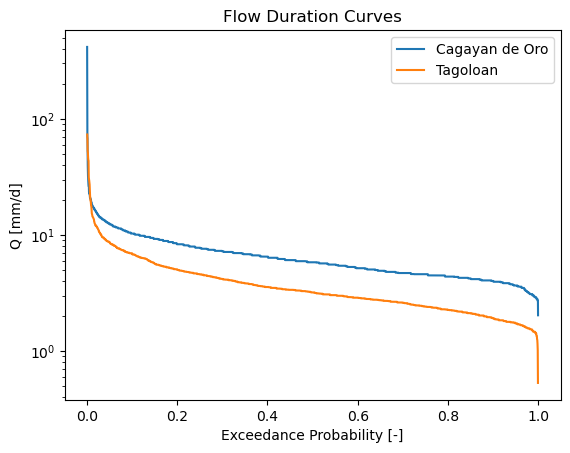

In [19]:
# Flow duration curve based on 5 years of discharge data 
# Cagayan de Oro
Q = Cagayan["Q mm/d"].loc['2003-01-01':'2012-12-31']
Q_sorted = Q.sort_values(ascending=False)
rank = np.arange(1, len(Q) + 1)
n_data = len(Q)
p_ex = rank / (n_data + 1)

# Tagoloan
Q2 = Tagoloan["Q mm/d"].loc['2013-01-01':'2019-12-31']
Q2_sorted = Q2.sort_values(ascending=False)
rank2 = np.arange(1, len(Q2) + 1)
n_data2 = len(Q2)
p_ex2 = rank2 / (n_data2 + 1)

plt.plot(p_ex, Q_sorted, label='Cagayan de Oro')
plt.plot(p_ex2, Q2_sorted, label='Tagoloan')
plt.title('Flow Duration Curves')
plt.yscale('log')
plt.xlabel('Exceedance Probability [-]')
plt.ylabel('Q [mm/d]')
plt.legend(); 

# Processes 1.3: Autocorrelaton

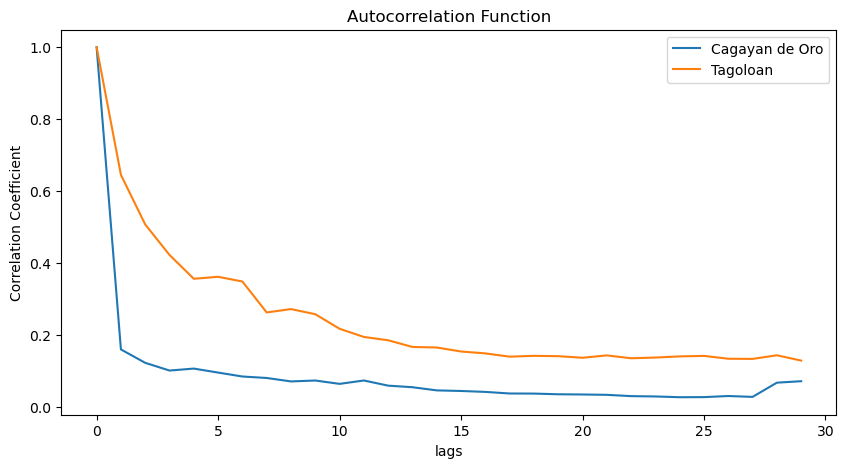

In [20]:
# Auto correlation based on 10 years of discharge data Cagayan de Oro
Q = Cagayan["Q mm/d"]
Q2 = Tagoloan["Q mm/d"]

# Autocorrelation Cagayan de Oro
lags = np.arange(30)
acf = pd.Series(
    [Q.autocorr(lag) for lag in lags])

# Autocorrelation Tagoloan
lags2 = np.arange(30)
acf2 = pd.Series(
    [Q2.autocorr(lag) for lag in lags2])

plt.figure(figsize=(10,5))
acf.plot(xlabel='lags', ylabel='Correlation Coefficient', label='Cagayan de Oro')
acf2.plot(xlabel='lags', ylabel='Correlation Coefficient', label='Tagoloan')
plt.legend()
plt.title('Autocorrelation Function');

# Processes 2.1: Interception

In [21]:
C_evap.name = "EP mm/d" 
C_prec.name = "P mm/d"
C_obs_data = C_obs['Q'].to_xarray().rename({'Day': 'time'})
C_obs_data.name = "Q mm/d"

df = xr.merge([C_prec, C_evap, C_obs_data]).to_dataframe()
Cagayan = df[["P mm/d", "EP mm/d", "Q mm/d"]].dropna()
Cagayan.index = pd.to_datetime(Cagayan.index)
Cagayan_pre_deforestation = Cagayan.loc["1991-01-01":"1994-12-31"]
Cagayan_post_deforestation = Cagayan.loc["1996-01-01":"1999-12-31"]
Cagayan_pre_deforestation

,P mm/d,EP mm/d,Q mm/d
time,,,
1991-01-16,2.945107,2.031221,3.533596
1991-01-17,1.071095,2.083669,3.190605
1991-01-18,2.552277,2.799082,3.190605
1991-01-19,13.945623,1.719752,3.190605
1991-01-20,15.782014,2.488085,3.190605
...,...,...,...
1994-12-27,1.033706,3.710000,4.722096
1994-12-28,2.127699,3.613030,4.594472
1994-12-29,0.205144,3.702114,4.594472


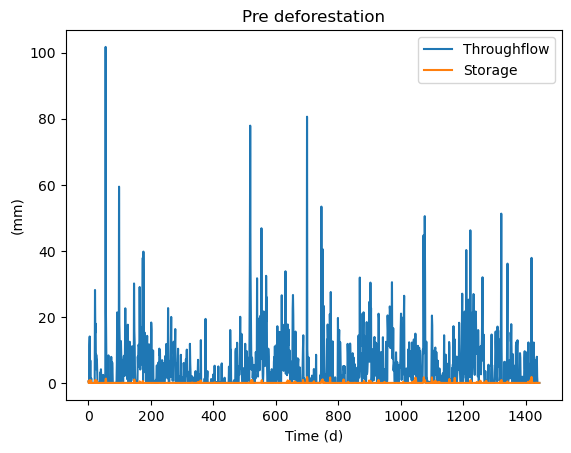

In [22]:
# Cagayan pre deforestation
Smax = 2.5 #mm
S = np.zeros(len(Cagayan_pre_deforestation['P mm/d']))
Pe = np.zeros(len(Cagayan_pre_deforestation['P mm/d']))
Ei = np.zeros(len(Cagayan_pre_deforestation['P mm/d']))
P = Cagayan_pre_deforestation['P mm/d']
EP = Cagayan_pre_deforestation['EP mm/d']

for i in range(len(P)):
    if i == 0:
        S[i] = P[i]
    else:
        S[i] = S[i-1] + P[i]
    
    if S[i] > Smax:
        Pe[i] = S[i] - Smax
        S[i] = Smax

    Ei[i] = np.minimum(S[i], EP[i])
    S[i] -= Ei[i]

df_pre = pd.DataFrame(index=Cagayan_pre_deforestation.index)
df_pre['S'] = S
df_pre['P'] = P
df_pre['Ei'] = Ei
df_pre['Pe'] = Pe

t = np.arange(len(S))
plt.plot(t, Pe, label='Throughflow')
plt.plot(t, S, label='Storage')
# plt.plot(t, Ei, label='Evaporation')
# plt.plot(t, P, label='Precipitation')
plt.title('Pre deforestation')
plt.xlabel('Time (d)')
plt.ylabel('(mm)')
plt.legend()

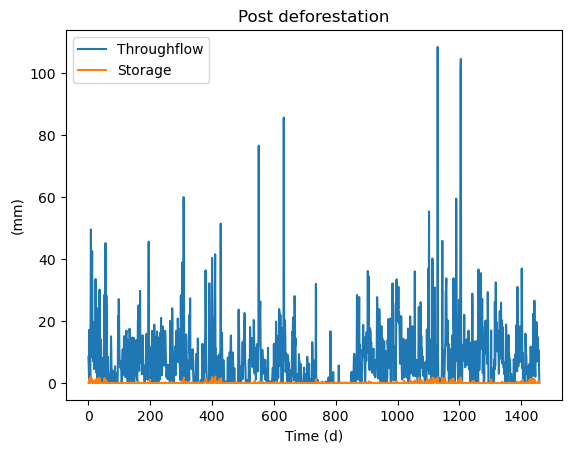

In [23]:
# Cagayan post deforestation
Smax = 2.5 #mm
S = np.zeros(len(Cagayan_post_deforestation['P mm/d']))
Pe = np.zeros(len(Cagayan_post_deforestation['P mm/d']))
Ei = np.zeros(len(Cagayan_post_deforestation['P mm/d']))
P = Cagayan_post_deforestation['P mm/d']
EP = Cagayan_post_deforestation['EP mm/d']

for i in range(len(P)):
    if i == 0:
        S[i] = P[i]
    else:
        S[i] = S[i-1] + P[i]
    
    if S[i] > Smax:
        Pe[i] = S[i] - Smax
        S[i] = Smax

    Ei[i] = np.minimum(S[i], EP[i])
    S[i] -= Ei[i]

df_post = pd.DataFrame(index=Cagayan_post_deforestation.index)
df_post['S'] = S
df_post['P'] = P
df_post['Ei'] = Ei
df_post['Pe'] = Pe

t = np.arange(len(S))
plt.plot(t, Pe, label='Throughflow')
plt.plot(t, S, label='Storage')
# plt.plot(t, Ei, label='Evaporation')
# plt.plot(t, P, label='Precipitation')
plt.title('Post deforestation')
plt.xlabel('Time (d)')
plt.ylabel('(mm)')
plt.legend()

In [24]:
df_pre.head(10)

,S,P,Ei,Pe
time,,,,
1991-01-16,0.468779,2.945107,2.031221,0.445107
1991-01-17,0.000000,1.071095,1.539873,0.000000
1991-01-18,0.000000,2.552277,2.500000,0.052277
1991-01-19,0.780248,13.945623,1.719752,11.445623
1991-01-20,0.011915,15.782014,2.488085,14.062262
1991-01-21,0.000000,1.365515,1.377430,0.000000
1991-01-22,0.587933,9.311430,1.912067,6.811430
1991-01-23,0.850294,2.597071,1.649706,0.685004
1991-01-24,0.000000,2.085510,2.500000,0.435804


In [25]:
df_post.head(10)

,S,P,Ei,Pe
time,,,,
1996-01-01,0.113893,10.916068,2.386107,8.416068
1996-01-02,0.387124,7.830940,2.112876,5.444833
1996-01-03,0.000000,3.287771,2.500000,1.174895
1996-01-04,1.135310,19.665817,1.364690,17.165817
1996-01-05,1.386926,6.960226,1.113074,5.595537
1996-01-06,0.000000,5.988144,2.500000,4.875070
1996-01-07,0.000000,3.674350,2.500000,1.174350
1996-01-08,0.337057,28.823189,2.162943,26.323189
1996-01-09,2.026686,51.712438,0.473314,49.549495


In [26]:
print(df_pre['Pe'].mean() / df_pre['P'].mean())
print(df_post['Pe'].mean() / df_post['P'].mean())

0.7251353509221916

0.7843154766068622

In [27]:
print(df_pre["Ei"].sum())
print(df_post["Ei"].sum())

2909.6465424538974

3100.530099036

In [28]:
print(df_pre["S"].sum())
print(df_post["S"].sum())

64.92348327417858

109.23556816123892

In [29]:
print(df_pre["P"].sum())
print(df_post["P"].sum())

10585.743027399054

14375.301715017009

# Processes 2.2: Rootzone storage

In [30]:
ET_LT_pre = Cagayan_pre_deforestation['P mm/d'].mean() - Cagayan_pre_deforestation['Q mm/d'].mean()
df2_pre = pd.DataFrame(index=Cagayan_pre_deforestation.index)
print(ET_LT_pre)

2.005775875747444

In [31]:
ET_pre = Cagayan_pre_deforestation['EP mm/d'] * (ET_LT_pre / Cagayan_pre_deforestation['EP mm/d'].mean())
df2_pre['ET_pre'] = ET_pre
print(ET_pre)

time
1991-01-16    1.161849
1991-01-17    1.191849
1991-01-18    1.601062
1991-01-19    0.983690
1991-01-20    1.423173
                ...   
1994-12-27    2.122103
1994-12-28    2.066637
1994-12-29    2.117592
1994-12-30    1.896671
1994-12-31    2.071364
Name: EP mm/d, Length: 1445, dtype: float64

In [32]:
SD_pre = np.zeros(len(Cagayan_pre_deforestation['P mm/d']))

for i in range(len(SD_pre)):
    SD_pre[i] = np.minimum(0, SD_pre[i-1] + Cagayan_pre_deforestation['P mm/d'][i] - ET_pre[i])

df2_pre['SD_pre'] = SD_pre

The maximum storage deficit pre deforestation (1991-1994) is -49.30.

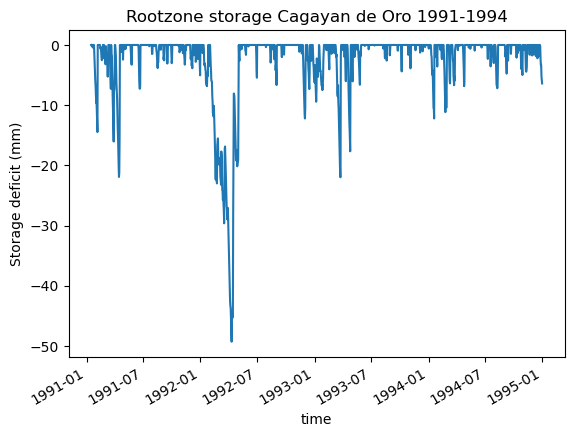

In [33]:
df2_pre['SD_pre'].plot()
plt.title("Rootzone storage Cagayan de Oro 1991-1994")
plt.ylabel("Storage deficit (mm)")
print(f'The maximum storage deficit pre deforestation (1991-1994) is {df2_pre['SD_pre'].min():.2f}.')

In [34]:
ET_LT_post = Cagayan_post_deforestation['P mm/d'].mean() - Cagayan_post_deforestation['Q mm/d'].mean()
df2_post = pd.DataFrame(index=Cagayan_post_deforestation.index)
print(ET_LT_post)

2.482939118425353

In [35]:
ET_post = Cagayan_post_deforestation['EP mm/d'] * (ET_LT_post / Cagayan_post_deforestation['EP mm/d'].mean())
df2_post['ET_post'] = ET_post
print(ET_post)

time
1996-01-01    1.693972
1996-01-02    1.499997
1996-01-03    1.947691
1996-01-04    0.968836
1996-01-05    0.790206
                ...   
1999-12-27    1.465411
1999-12-28    1.470338
1999-12-29    1.243233
1999-12-30    1.365425
1999-12-31    2.335555
Name: EP mm/d, Length: 1460, dtype: float64

In [36]:
SD_post = np.zeros(len(Cagayan_post_deforestation['P mm/d']))

for i in range(len(SD_post)):
    SD_post[i] = np.minimum(0, SD_post[i-1] + Cagayan_post_deforestation['P mm/d'][i] - ET_post[i])

df2_post['SD_post'] = SD_post

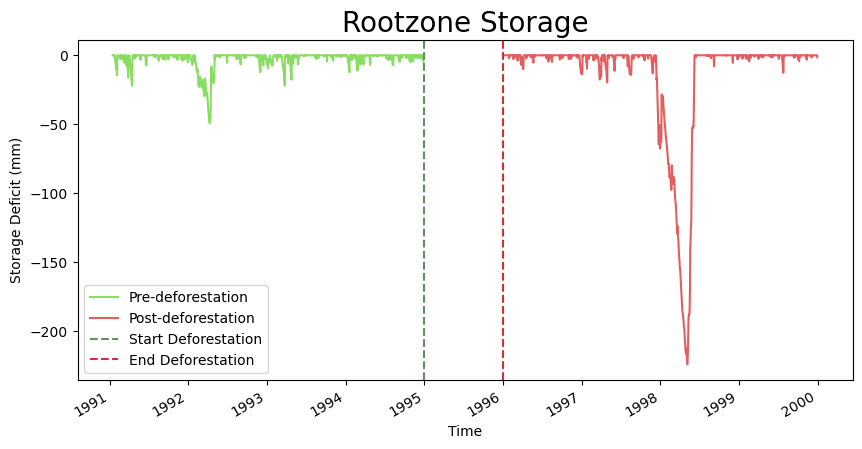

In [37]:
# Plot
plt.figure(figsize=(10, 5))
    
df2_pre['SD_pre'].plot(label='Pre-deforestation', color='#89DD63')
df2_post['SD_post'].plot(label='Post-deforestation', color='#E35E5E')
# plt.title("Rootzone storage pre and post deforestation Cagayan de Oro")
font = {'family': 'sans-serif', 'color': 'black', 'weight': 'normal', 'size': 10}
plt.title("Rootzone Storage", fontdict=font, fontsize=20)
plt.ylabel("Storage Deficit (mm)", fontdict=font)
plt.xlabel('Time', fontdict=font)
plt.axvline(x='1995-01-01', color='#60905B', linestyle='--', label='Start Deforestation')
plt.axvline(x='1996-01-01', color='#D52E31', linestyle='--', label='End Deforestation')
plt.legend()

# Processes 2.3: Budyko

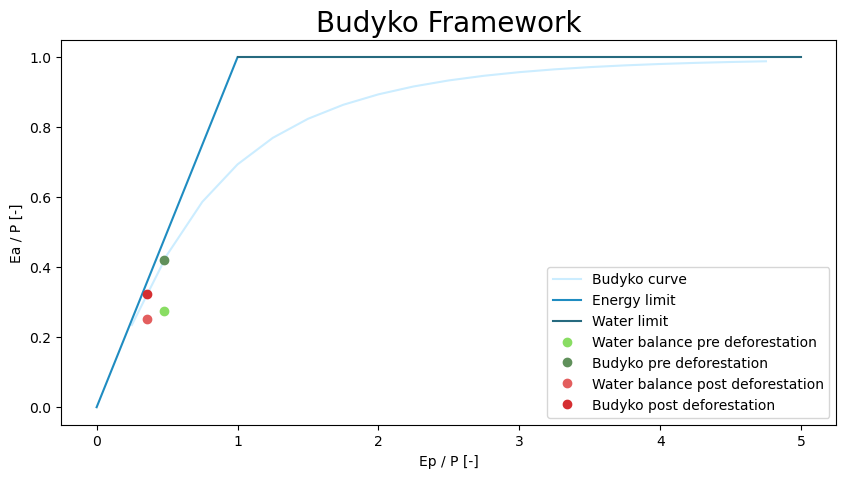

In [38]:
ep_p = np.arange(0.25, 5, 0.25)
budyko = (ep_p * np.tanh(1 / ep_p) * (1 - np.exp(-ep_p))) ** 0.5

EP_P_1 = Cagayan_pre_deforestation['EP mm/d'].mean() / Cagayan_pre_deforestation['P mm/d'].mean()
ET_P_1 = df2_pre['ET_pre'].mean() / Cagayan_pre_deforestation['P mm/d'].mean()
budyko1 = (EP_P_1 * np.tanh(1 / EP_P_1) * (1 - np.exp(-EP_P_1))) ** 0.5

EP_P_2 = Cagayan_post_deforestation['EP mm/d'].mean() / Cagayan_post_deforestation['P mm/d'].mean()
ET_P_2 = df2_post['ET_post'].mean() / Cagayan_post_deforestation['P mm/d'].mean()
budyko2 = (EP_P_2 * np.tanh(1 / EP_P_2) * (1 - np.exp(-EP_P_2))) ** 0.5

plt.figure(figsize=(10, 5))

plt.plot(ep_p, budyko, color='#CCEDFF', label='Budyko curve')
plt.plot([0, 1], [0, 1], color='#1F8CC1', label='Energy limit')
plt.plot([1, 5], [1, 1], color='#266A7F', label='Water limit')

plt.plot(EP_P_1, ET_P_1, 'o', color='#89DD63', label='Water balance pre deforestation')
plt.plot(EP_P_1, budyko1, 'o', color='#60905B', label='Budyko pre deforestation')

plt.plot(EP_P_2, ET_P_2, 'o', color='#E35E5E', label='Water balance post deforestation')
plt.plot(EP_P_2, budyko2, 'o', color='#D52E31', label='Budyko post deforestation')
# plt.title('Budyko Framework Deforestation Cagayan de Oro')
plt.title('Budyko Framework', fontdict=font, fontsize=20)
plt.legend()
plt.xlabel('Ep / P [-]', fontdict=font)
plt.ylabel('Ea / P [-]', fontdict=font)
plt.show();